<a href="https://colab.research.google.com/github/2303A52420/Exp-AI/blob/main/EAI_lab_exam_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [13]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler, StandardScaler
import warnings
warnings.filterwarnings('ignore')


In [14]:
# Load your dataset
df = pd.read_csv("/content/eeg-headset.csv")

print("Shape:", df.shape)
print(df.head())


Shape: (14980, 15)
       AF3       F7       F3      FC5       T7        P       O1       O2  \
0  4329.23  4009.23  4289.23  4148.21  4350.26  4586.15  4096.92  4641.03   
1  4324.62  4004.62  4293.85  4148.72  4342.05  4586.67  4097.44  4638.97   
2  4327.69  4006.67  4295.38  4156.41  4336.92  4583.59  4096.92  4630.26   
3  4328.72  4011.79  4296.41  4155.90  4343.59  4582.56  4097.44  4630.77   
4  4326.15  4011.79  4292.31  4151.28  4347.69  4586.67  4095.90  4627.69   

        P8       T8      FC6       F4       F8      AF4  eye_state  
0  4222.05  4238.46  4211.28  4280.51  4635.90  4393.85          1  
1  4210.77  4226.67  4207.69  4279.49  4632.82  4384.10          1  
2  4207.69  4222.05  4206.67  4282.05  4628.72  4389.23          1  
3  4217.44  4235.38  4210.77  4287.69  4632.31  4396.41          1  
4  4210.77  4244.10  4212.82  4288.21  4632.82  4398.46          1  


Handle Missing Values (basic)

In [15]:
# Fill numeric NaNs with median values (recommended for scaling)
df = df.fillna(df.median(numeric_only=True))

# If any non-numeric columns exist, keep them aside
num_df = df.select_dtypes(include=[np.number])
cat_df = df.select_dtypes(exclude=[np.number])

print("Numeric columns:", num_df.columns.tolist())
print("Categorical columns:", cat_df.columns.tolist())


Numeric columns: ['AF3', 'F7', 'F3', 'FC5', 'T7', 'P', 'O1', 'O2', 'P8', 'T8', 'FC6', 'F4', 'F8', 'AF4', 'eye_state']
Categorical columns: []


Min-Max Normalization (Range [0, 1])

In [16]:
# Initialize the MinMaxScaler
minmax_scaler = MinMaxScaler()

# Apply scaling only to numeric columns
df_minmax = num_df.copy()
df_minmax[df_minmax.columns] = minmax_scaler.fit_transform(num_df)

# Combine scaled numeric + original categorical columns
df_minmax_scaled = pd.concat([df_minmax, cat_df], axis=1)

print("✅ Min-Max Scaling complete!")
display(df_minmax_scaled.head())


✅ Min-Max Scaling complete!


,AF3,F7,F3,FC5,T7,P,O1,O2,P8,T8,FC6,F4,F8,AF4,eye_state
0,0.010702,0.236931,0.556326,0.002648,0.515557,0.005053,0.003558,0.027383,0.010837,0.498575,0.264230,0.426286,0.029886,0.004237,0.0
1,0.010687,0.236004,0.557117,0.002649,0.513684,0.005054,0.003559,0.026619,0.010795,0.496148,0.263219,0.426071,0.029865,0.004224,0.0
2,0.010697,0.236416,0.557379,0.002661,0.512514,0.005046,0.003558,0.023390,0.010783,0.495197,0.262931,0.426610,0.029838,0.004231,0.0
3,0.010701,0.237446,0.557556,0.002660,0.514035,0.005043,0.003559,0.023579,0.010820,0.497940,0.264086,0.427799,0.029862,0.004241,0.0
4,0.010692,0.237446,0.556854,0.002653,0.514971,0.005054,0.003556,0.022437,0.010795,0.499735,0.264664,0.427909,0.029865,0.004244,0.0


Z-Score Normalization (Standardization)

In [17]:
# Initialize the StandardScaler
zscore_scaler = StandardScaler()

# Apply scaling only to numeric columns
df_zscore = num_df.copy()
df_zscore[df_zscore.columns] = zscore_scaler.fit_transform(num_df)

# Combine scaled numeric + categorical columns
df_zscore_scaled = pd.concat([df_zscore, cat_df], axis=1)

print("✅ Z-Score (Standardization) complete!")
display(df_zscore_scaled.head())


✅ Z-Score (Standardization) complete!


,AF3,F7,F3,FC5,T7,P,O1,O2,P8,T8,FC6,F4,F8,AF4,eye_state
0,0.002934,-0.011704,0.567398,-0.003209,0.245236,-0.019788,-0.002930,0.852568,0.001509,0.187750,0.233510,0.030745,0.017127,-0.003834,-0.90234
1,0.001084,-0.112052,0.671390,-0.003111,0.008893,-0.019610,-0.002817,0.782241,-0.003771,-0.122109,0.138498,0.006192,0.014578,-0.005489,-0.90234
2,0.002316,-0.067429,0.705829,-0.001636,-0.138785,-0.020663,-0.002930,0.484886,-0.005213,-0.243529,0.111503,0.067815,0.011185,-0.004618,-0.90234
3,0.002730,0.044020,0.729013,-0.001734,0.053225,-0.021015,-0.002817,0.502297,-0.000649,0.106803,0.220012,0.203578,0.014156,-0.003399,-0.90234
4,0.001698,0.044020,0.636726,-0.002620,0.171253,-0.019610,-0.003152,0.397148,-0.003771,0.335977,0.274267,0.216095,0.014578,-0.003051,-0.90234


Save the Scaled Data (optional)

In [19]:
df_minmax_scaled.to_csv("dataset_minmax_scaled.csv", index=False)
df_zscore_scaled.to_csv("dataset_zscore_scaled.csv", index=False)
print("✅ Saved both scaled datasets to disk.")


✅ Saved both scaled datasets to disk.


In [20]:
import pandas as pd

# Load CSV
df = pd.read_csv("eeg-headset.csv")

# Display first few rows
print(df.head())

# Check basic info
print(df.info())

# Check missing values
print(df.isnull().sum())


       AF3       F7       F3      FC5       T7        P       O1       O2  \
0  4329.23  4009.23  4289.23  4148.21  4350.26  4586.15  4096.92  4641.03   
1  4324.62  4004.62  4293.85  4148.72  4342.05  4586.67  4097.44  4638.97   
2  4327.69  4006.67  4295.38  4156.41  4336.92  4583.59  4096.92  4630.26   
3  4328.72  4011.79  4296.41  4155.90  4343.59  4582.56  4097.44  4630.77   
4  4326.15  4011.79  4292.31  4151.28  4347.69  4586.67  4095.90  4627.69   

        P8       T8      FC6       F4       F8      AF4  eye_state  
0  4222.05  4238.46  4211.28  4280.51  4635.90  4393.85          1  
1  4210.77  4226.67  4207.69  4279.49  4632.82  4384.10          1  
2  4207.69  4222.05  4206.67  4282.05  4628.72  4389.23          1  
3  4217.44  4235.38  4210.77  4287.69  4632.31  4396.41          1  
4  4210.77  4244.10  4212.82  4288.21  4632.82  4398.46          1  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14980 entries, 0 to 14979
Data columns (total 15 columns):
 #   Column   

Handle Missing Values (Null Value Handling)
Option 1: Remove Rows or Columns

In [21]:
# Remove rows with any missing values
df_cleaned = df.dropna()

# OR remove columns with too many missing values
df_cleaned = df.dropna(axis=1)


Impute Missing Values

Mean / Median / Mode Imputation:


In [23]:
# Example: For numeric columns, replace 'column_name' with actual column names
# Impute missing values in the 'AF3' column with its mean
df['AF3'].fillna(df['AF3'].mean(), inplace=True)

# Impute missing values in the 'F7' column with its median
df['F7'].fillna(df['F7'].median(), inplace=True)

# You can similarly apply this to other numeric columns as needed.

# Note: Based on the previous output, there are no categorical columns in this dataset.
# If you had categorical columns, you would use mode imputation like this:
# df['category_col'].fillna(df['category_col'].mode()[0], inplace=True) # Mode

print("✅ Example imputation code updated.")

✅ Example imputation code updated.


In [24]:
num_cols = df.select_dtypes(include=['float64', 'int64']).columns
df[num_cols] = df[num_cols].fillna(df[num_cols].mean())


Handle Class Imbalance

In [26]:
print(df['eye_state'].value_counts())

eye_state
1    8257
2    6723
Name: count, dtype: int64


Random Oversampling (Simple)

In [28]:
from sklearn.utils import resample

# Separate majority and minority classes
majority = df[df['eye_state'] == df['eye_state'].value_counts().idxmax()]
minority = df[df['eye_state'] == df['eye_state'].value_counts().idxmin()]

# Oversample minority
minority_upsampled = resample(minority,
                              replace=True,     # sample with replacement
                              n_samples=len(majority),    # match majority
                              random_state=42)

# Combine
df_balanced = pd.concat([majority, minority_upsampled])

print(df_balanced['eye_state'].value_counts())

eye_state
1    8257
2    8257
Name: count, dtype: int64


SMOTE (Synthetic Minority Over-sampling Technique)

In [30]:
from sklearn.model_selection import train_test_split

# Split features and target - Use df_balanced created in the previous step
# X = df_balanced.drop('eye_state', axis=1)
# y = df_balanced['eye_state']

# Train-test split - Apply this after splitting df_balanced into X and y
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# SMOTE is not needed as Random Oversampling was performed in the previous step
# smote = SMOTE(random_state=42)
# X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

# print("Before SMOTE:", y_train.value_counts())
# print("After SMOTE:", y_train_res.value_counts())

# This cell is no longer necessary since Random Oversampling was performed.
# You can proceed by splitting df_balanced into features (X) and target (y).

ADASYN (Adaptive Synthetic Sampling)

In [31]:
from imblearn.over_sampling import ADASYN

adasyn = ADASYN(random_state=42)
X_train_res, y_train_res = adasyn.fit_resample(X_train, y_train)

print("Before ADASYN:", y_train.value_counts())
print("After ADASYN:", y_train_res.value_counts())


Before ADASYN: eye_state
1    6606
2    5378
Name: count, dtype: int64
After ADASYN: eye_state
1    6606
2    6452
Name: count, dtype: int64


correlation

       AF3       F7       F3      FC5       T7        P       O1       O2  \
0  4329.23  4009.23  4289.23  4148.21  4350.26  4586.15  4096.92  4641.03   
1  4324.62  4004.62  4293.85  4148.72  4342.05  4586.67  4097.44  4638.97   
2  4327.69  4006.67  4295.38  4156.41  4336.92  4583.59  4096.92  4630.26   
3  4328.72  4011.79  4296.41  4155.90  4343.59  4582.56  4097.44  4630.77   
4  4326.15  4011.79  4292.31  4151.28  4347.69  4586.67  4095.90  4627.69   

        P8       T8      FC6       F4       F8      AF4  eye_state  
0  4222.05  4238.46  4211.28  4280.51  4635.90  4393.85          1  
1  4210.77  4226.67  4207.69  4279.49  4632.82  4384.10          1  
2  4207.69  4222.05  4206.67  4282.05  4628.72  4389.23          1  
3  4217.44  4235.38  4210.77  4287.69  4632.31  4396.41          1  
4  4210.77  4244.10  4212.82  4288.21  4632.82  4398.46          1  

Correlation Matrix:
                AF3        F7        F3       FC5        T7         P  \
AF3        1.000000  0.261146

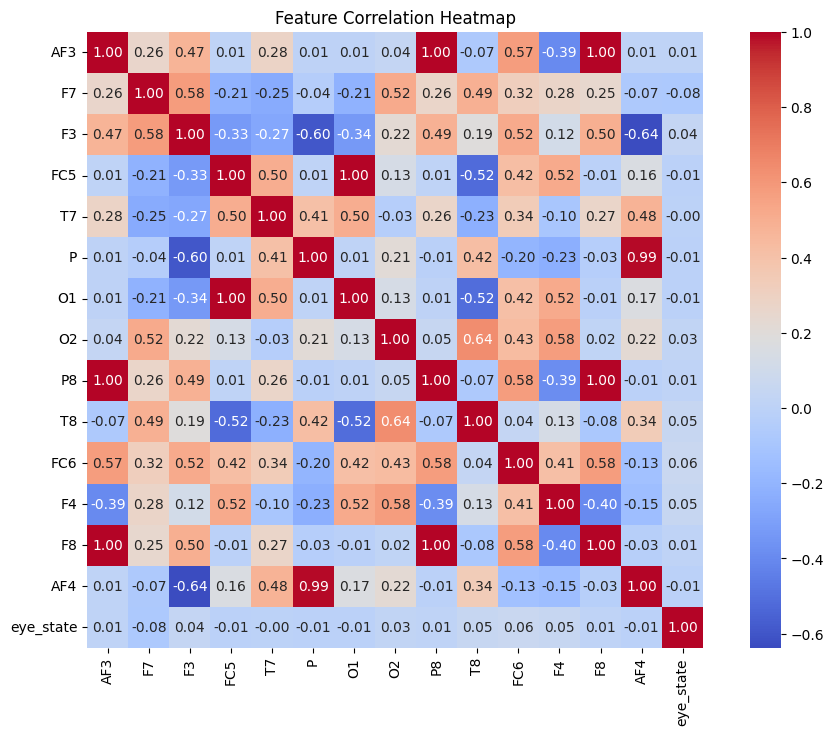


Highly correlated features (|corr| > 0.85):
['O1', 'P8', 'F8', 'AF4']

Reduced dataset shape: (14980, 11)


In [32]:
# Import libraries
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("eeg-headset.csv")

# Display first few rows
print(df.head())

# -----------------------------
# 1️⃣ Compute Correlation Matrix
# -----------------------------
corr_matrix = df.corr(numeric_only=True)

print("\nCorrelation Matrix:")
print(corr_matrix)

# ----------------------------------------
# 2️⃣ Visualize with a Seaborn Heatmap
# ----------------------------------------
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", square=True)
plt.title("Feature Correlation Heatmap")
plt.show()

# ------------------------------------------------------
# 3️⃣ Identify Highly Correlated Features (|corr| > 0.85)
# ------------------------------------------------------
# Take upper triangle of correlation matrix to avoid duplicate pairs
upper_tri = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

# Find features with correlation greater than 0.85
high_corr_features = [
    column for column in upper_tri.columns if any(upper_tri[column].abs() > 0.85)
]

print("\nHighly correlated features (|corr| > 0.85):")
print(high_corr_features)

# -------------------------------------------------
# 4️⃣ Optionally Remove Highly Correlated Features
# -------------------------------------------------
df_reduced = df.drop(columns=high_corr_features)
print(f"\nReduced dataset shape: {df_reduced.shape}")


In [33]:
# Step 1: Setup & imports
# Run this cell first

# If you need to install packages in your environment, uncomment and run the pip lines:
# !pip install scikit-learn seaborn matplotlib pandas imbalanced-learn shap

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, roc_auc_score, roc_curve, auc)

# For models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neural_network import MLPClassifier

# For permutation importance fallback
from sklearn.inspection import permutation_importance

# Optional: imblearn (SMOTE/ADASYN) and shap (explainability)
try:
    from imblearn.over_sampling import SMOTE, ADASYN, RandomOverSampler
    IMBLEARN_AVAILABLE = True
except Exception:
    IMBLEARN_AVAILABLE = False

try:
    import shap
    SHAP_AVAILABLE = True
except Exception:
    SHAP_AVAILABLE = False

# File paths and constants
CSV_PATH = "/content/eeg-headset.csv"
OUTDIR = "/mnt/data/eeg_analysis_outputs"
os.makedirs(OUTDIR, exist_ok=True)

# Target column (change if you want different target)
TARGET_COL = "eye_state"   # change this if needed


In [34]:
# Step 2: Load dataset & quick checks
df = pd.read_csv(CSV_PATH)
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())

# Show head and datatypes
display(df.head())
print("\nDtypes:\n", df.dtypes)

# Missing values
print("\nMissing values per column:\n", df.isnull().sum())

# Basic numeric summary
print("\nNumeric summary:")
display(df.describe().T)


Shape: (14980, 15)
Columns: ['AF3', 'F7', 'F3', 'FC5', 'T7', 'P', 'O1', 'O2', 'P8', 'T8', 'FC6', 'F4', 'F8', 'AF4', 'eye_state']


,AF3,F7,F3,FC5,T7,P,O1,O2,P8,T8,FC6,F4,F8,AF4,eye_state
0,4329.23,4009.23,4289.23,4148.21,4350.26,4586.15,4096.92,4641.03,4222.05,4238.46,4211.28,4280.51,4635.90,4393.85,1
1,4324.62,4004.62,4293.85,4148.72,4342.05,4586.67,4097.44,4638.97,4210.77,4226.67,4207.69,4279.49,4632.82,4384.10,1
2,4327.69,4006.67,4295.38,4156.41,4336.92,4583.59,4096.92,4630.26,4207.69,4222.05,4206.67,4282.05,4628.72,4389.23,1
3,4328.72,4011.79,4296.41,4155.90,4343.59,4582.56,4097.44,4630.77,4217.44,4235.38,4210.77,4287.69,4632.31,4396.41,1
4,4326.15,4011.79,4292.31,4151.28,4347.69,4586.67,4095.90,4627.69,4210.77,4244.10,4212.82,4288.21,4632.82,4398.46,1



Dtypes:
 AF3          float64
F7           float64
F3           float64
FC5          float64
T7           float64
P            float64
O1           float64
O2           float64
P8           float64
T8           float64
FC6          float64
F4           float64
F8           float64
AF4          float64
eye_state      int64
dtype: object

Missing values per column:
 AF3          0
F7           0
F3           0
FC5          0
T7           0
P            0
O1           0
O2           0
P8           0
T8           0
FC6          0
F4           0
F8           0
AF4          0
eye_state    0
dtype: int64

Numeric summary:


,count,mean,std,min,25%,50%,75%,max
AF3,14980.0,4321.917777,2492.072174,1030.7700,4280.51,4294.36,4311.79,309231.00
F7,14980.0,4009.767694,45.941672,2830.7700,3990.77,4005.64,4023.08,7804.62
F3,14980.0,4264.022433,44.428052,1040.0000,4250.26,4262.56,4270.77,6880.51
FC5,14980.0,4164.946326,5216.404632,2453.3300,4108.21,4120.51,4132.31,642564.00
T7,14980.0,4341.741075,34.738821,2089.7400,4331.79,4338.97,4347.18,6474.36
P,14980.0,4644.022379,2924.789537,2768.2100,4611.79,4617.95,4626.67,362564.00
O1,14980.0,4110.400160,4600.926543,2086.1500,4057.95,4070.26,4083.59,567179.00
O2,14980.0,4616.056904,29.292603,4567.1800,4604.62,4613.33,4624.10,7264.10
P8,14980.0,4218.826610,2136.408523,1357.9500,4190.77,4199.49,4209.23,265641.00
T8,14980.0,4231.316200,38.050903,1816.4100,4220.51,4229.23,4239.49,6674.36


Null value handling (impute or drop)

In [35]:
# Step 3: Null value handling
df3 = df.copy()

# Option A: Drop rows with any missing values
df_drop_rows = df3.dropna()
print("After drop rows shape:", df_drop_rows.shape)

# Option B: Drop columns with >50% missing
col_thresh = int(0.5 * len(df3))
df_drop_cols = df3.dropna(axis=1, thresh=col_thresh)
print("After drop cols shape:", df_drop_cols.shape)

# Option C: Impute numeric (mean) and categorical (mode)
num_cols = df3.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = df3.select_dtypes(include=['object', 'category', 'bool']).columns.tolist()

df_impute = df3.copy()
if num_cols:
    num_imputer = SimpleImputer(strategy="mean")
    df_impute[num_cols] = num_imputer.fit_transform(df_impute[num_cols])

for c in cat_cols:
    if df_impute[c].isnull().any():
        mode_val = df_impute[c].mode()[0] if not df_impute[c].mode().empty else "missing"
        df_impute[c].fillna(mode_val, inplace=True)

print("After imputation missing counts:\n", df_impute.isnull().sum())


After drop rows shape: (14980, 15)
After drop cols shape: (14980, 15)
After imputation missing counts:
 AF3          0
F7           0
F3           0
FC5          0
T7           0
P            0
O1           0
O2           0
P8           0
T8           0
FC6          0
F4           0
F8           0
AF4          0
eye_state    0
dtype: int64


Correlation analysis + heatmap (find correlated features)

                AF3        F7        F3       FC5        T7         P  \
AF3        1.000000  0.261146  0.474569  0.012173  0.278938  0.007958   
F7         0.261146  1.000000  0.583317 -0.208922 -0.250816 -0.042288   
F3         0.474569  0.583317  1.000000 -0.330162 -0.272186 -0.596566   
FC5        0.012173 -0.208922 -0.330162  1.000000  0.504616  0.009049   
T7         0.278938 -0.250816 -0.272186  0.504616  1.000000  0.409277   
P          0.007958 -0.042288 -0.596566  0.009049  0.409277  1.000000   
O1         0.006630 -0.210591 -0.335514  0.999961  0.504231  0.013707   
O2         0.040539  0.517816  0.221270  0.130482 -0.030063  0.208167   
P8         0.999607  0.264922  0.486506  0.013228  0.264913 -0.012528   
T8        -0.070801  0.489010  0.191273 -0.519498 -0.225508  0.420539   
FC6        0.572997  0.317418  0.517950  0.420311  0.336173 -0.196873   
F4        -0.394334  0.275977  0.116761  0.515388 -0.095902 -0.229149   
F8         0.998714  0.251327  0.500276 -0.005351  

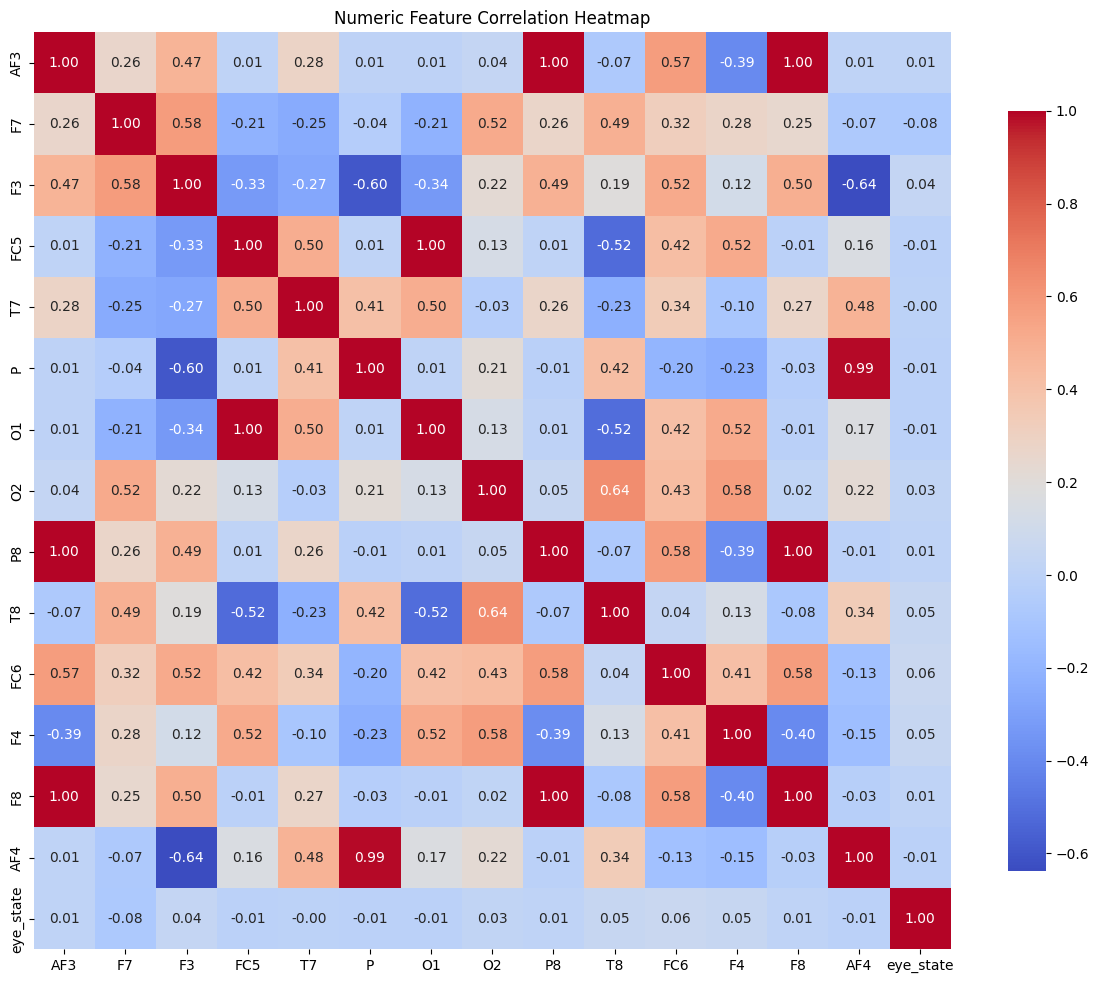

Saved heatmap to: /mnt/data/eeg_analysis_outputs/correlation_heatmap.png
Highly correlated columns to consider dropping (|corr| > 0.85): ['O1', 'P8', 'F8', 'AF4']
Highly correlated pairs (a, b, corr): [('AF3', 'P8', np.float64(0.9996066187213823)), ('AF3', 'F8', np.float64(0.9987140947598644)), ('FC5', 'O1', np.float64(0.9999610708874176)), ('P', 'AF4', np.float64(0.988310438201499)), ('P8', 'F8', np.float64(0.9988494382235333))]


In [36]:
# Step 4: Correlation matrix and heatmap
df_corr_source = df_impute  # use the imputed dataframe from previous step

numeric_cols = df_corr_source.select_dtypes(include=[np.number]).columns.tolist()
corr_matrix = df_corr_source[numeric_cols].corr()

# Print correlation matrix
print(corr_matrix)

# Plot heatmap (seaborn)
plt.figure(figsize=(12,10))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", square=True, cbar_kws={"shrink": .8})
plt.title("Numeric Feature Correlation Heatmap")
plt.tight_layout()
heatmap_file = os.path.join(OUTDIR, "correlation_heatmap.png")
plt.savefig(heatmap_file, dpi=150)
plt.show()
print("Saved heatmap to:", heatmap_file)

# Identify highly correlated feature columns (|corr| > 0.85)
import numpy as np
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
threshold = 0.85
high_corr_cols = [col for col in upper.columns if any(upper[col].abs() > threshold)]
print("Highly correlated columns to consider dropping (|corr| > 0.85):", high_corr_cols)

# Also print pairs for inspection
high_corr_pairs = []
for i in range(len(numeric_cols)):
    for j in range(i+1, len(numeric_cols)):
        a, b = numeric_cols[i], numeric_cols[j]
        val = corr_matrix.loc[a, b]
        if abs(val) > threshold:
            high_corr_pairs.append((a, b, val))
print("Highly correlated pairs (a, b, corr):", high_corr_pairs)


Remove highly correlated features

In [37]:
# Step 5: Drop highly correlated features (one side)
df_reduced = df_impute.copy()
if len(high_corr_cols) > 0:
    df_reduced = df_reduced.drop(columns=high_corr_cols)
print("Reduced dataframe shape:", df_reduced.shape)
# Save reduced CSV
reduced_csv = os.path.join(OUTDIR, "eeg_reduced.csv")
df_reduced.to_csv(reduced_csv, index=False)
print("Saved reduced dataset to:", reduced_csv)


Reduced dataframe shape: (14980, 11)
Saved reduced dataset to: /mnt/data/eeg_analysis_outputs/eeg_reduced.csv


Handle class imbalance (SMOTE / ADASYN / RandomOverSampler)

In [38]:
# Step 6: Handle class imbalance
from sklearn.preprocessing import OneHotEncoder

# Select target
if TARGET_COL not in df_reduced.columns:
    raise ValueError(f"Target column '{TARGET_COL}' not found in the dataset. Change TARGET_COL variable.")
X = df_reduced.drop(columns=[TARGET_COL])
y = df_reduced[TARGET_COL].copy()

# Encode target if categorical
le = LabelEncoder()
if y.dtype == 'object' or y.dtype.name == 'category' or y.dtype == bool:
    y_enc = le.fit_transform(y)
else:
    y_enc = y.values

# Convert features to numeric matrix: one-hot encode categorical features if any
cat_feats = X.select_dtypes(include=['object', 'category', 'bool']).columns.tolist()
num_feats = X.select_dtypes(include=[np.number]).columns.tolist()

if cat_feats:
    # one-hot encode categorical features
    X_ohe = pd.get_dummies(X, columns=cat_feats, drop_first=True)
else:
    X_ohe = X.copy()

print("Feature matrix shape before resampling:", X_ohe.shape)
print("Target class counts:\n", pd.Series(y_enc).value_counts())

# Split first (so we don't leak)
X_train, X_test, y_train, y_test = train_test_split(X_ohe, y_enc, test_size=0.2, random_state=42, stratify=y_enc if len(np.unique(y_enc))>1 else None)

# Try SMOTE or ADASYN
if IMBLEARN_AVAILABLE:
    try:
        sm = SMOTE(random_state=42)
        X_train_res, y_train_res = sm.fit_resample(X_train, y_train)
        print("SMOTE applied. New class counts:\n", pd.Series(y_train_res).value_counts())
    except Exception as e:
        print("SMOTE failed, trying ADASYN:", e)
        try:
            ada = ADASYN(random_state=42)
            X_train_res, y_train_res = ada.fit_resample(X_train, y_train)
            print("ADASYN applied. New class counts:\n", pd.Series(y_train_res).value_counts())
        except Exception as e2:
            print("ADASYN failed, falling back to RandomOverSampler:", e2)
            ros = RandomOverSampler(random_state=42)
            X_train_res, y_train_res = ros.fit_resample(X_train, y_train)
            print("Random oversampler applied. New class counts:\n", pd.Series(y_train_res).value_counts())
else:
    # Simple upsampling fallback (pandas sample)
    print("imblearn not available -> using simple upsampling")
    df_tr = pd.concat([X_train.reset_index(drop=True), pd.Series(y_train, name='_target')], axis=1)
    maj_count = df_tr['_target'].value_counts().max()
    df_list = []
    for cls, grp in df_tr.groupby('_target'):
        df_list.append(grp.sample(maj_count, replace=True, random_state=42))
    df_bal = pd.concat(df_list).sample(frac=1, random_state=42).reset_index(drop=True)
    y_train_res = df_bal['_target'].values
    X_train_res = df_bal.drop(columns=['_target'])
    print("After simple upsampling class counts:\n", pd.Series(y_train_res).value_counts())

# After resampling, use X_train_res, y_train_res, and X_test, y_test for modeling


Feature matrix shape before resampling: (14980, 10)
Target class counts:
 1.0    8257
2.0    6723
Name: count, dtype: int64
SMOTE applied. New class counts:
 1.0    6606
2.0    6606
Name: count, dtype: int64


Feature scaling

In [39]:
# Step 7: Scaling numeric features
scaler = StandardScaler()
# Fit scaler on training data
# If X_train_res is a DataFrame, ensure consistent columns:
if isinstance(X_train_res, pd.DataFrame):
    X_train_cols = X_train_res.columns
else:
    X_train_cols = X_train.columns

# Fit transform training, transform testing (ensure columns align)
X_train_scaled = scaler.fit_transform(X_train_res)
X_test_scaled = scaler.transform(X_test[X_train_cols])  # X_test may have same columns as X_train_res


Train baseline models & evaluate (metrics + confusion matrix + AUC)

In [40]:
# Step 8: Train models and evaluate
models = {
    "LogisticRegression": LogisticRegression(max_iter=1000),
    "DecisionTree": DecisionTreeClassifier(random_state=42),
    "KNN": KNeighborsClassifier(),
    "RandomForest": RandomForestClassifier(n_estimators=100, random_state=42),
    "GradientBoosting": GradientBoostingClassifier(random_state=42),
    "MLP": MLPClassifier(max_iter=500, random_state=42)
}

results = {}
for name, mdl in models.items():
    try:
        mdl.fit(X_train_scaled, y_train_res)
        y_pred = mdl.predict(X_test_scaled)
        acc = accuracy_score(y_test, y_pred)
        prec = precision_score(y_test, y_pred, average='weighted', zero_division=0)
        rec = recall_score(y_test, y_pred, average='weighted', zero_division=0)
        f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)
        cm = confusion_matrix(y_test, y_pred)
        auc_score = None
        # AUC if binary
        if len(np.unique(y_enc)) == 2:
            try:
                y_proba = mdl.predict_proba(X_test_scaled)[:,1]
                auc_score = roc_auc_score(y_test, y_proba)
            except Exception:
                auc_score = None
        results[name] = {"model": mdl, "accuracy": acc, "precision": prec, "recall": rec, "f1": f1, "confusion_matrix": cm, "auc": auc_score}
    except Exception as e:
        results[name] = {"error": str(e)}

# Print results summary
for name, res in results.items():
    print(f"\nModel: {name}")
    if "error" in res:
        print("Error:", res["error"])
    else:
        print(f"Accuracy: {res['accuracy']:.4f}, Precision: {res['precision']:.4f}, Recall: {res['recall']:.4f}, F1: {res['f1']:.4f}, AUC: {res['auc']}")
        print("Confusion matrix:\n", res['confusion_matrix'])



Model: LogisticRegression
Accuracy: 0.5537, Precision: 0.5579, Recall: 0.5537, F1: 0.5549, AUC: 0.6060569351907934
Confusion matrix:
 [[920 731]
 [606 739]]

Model: DecisionTree
Accuracy: 0.7747, Precision: 0.7762, Recall: 0.7747, F1: 0.7751, AUC: 0.7745637993420682
Confusion matrix:
 [[1281  370]
 [ 305 1040]]

Model: KNN
Accuracy: 0.8792, Precision: 0.8800, Recall: 0.8792, F1: 0.8793, AUC: 0.9411126297231147
Confusion matrix:
 [[1446  205]
 [ 157 1188]]

Model: RandomForest
Accuracy: 0.8832, Precision: 0.8831, Recall: 0.8832, F1: 0.8831, AUC: 0.9536489094139182
Confusion matrix:
 [[1487  164]
 [ 186 1159]]

Model: GradientBoosting
Accuracy: 0.7690, Precision: 0.7699, Recall: 0.7690, F1: 0.7693, AUC: 0.8496101270155071
Confusion matrix:
 [[1285  366]
 [ 326 1019]]

Model: MLP
Accuracy: 0.8621, Precision: 0.8621, Recall: 0.8621, F1: 0.8621, AUC: 0.9362945516854717
Confusion matrix:
 [[1446  205]
 [ 208 1137]]


HAP explainability (global & summary plot) — model-agnostic approach

In [41]:
# Step 9: SHAP (try TreeExplainer for tree-based models) or permutation importance fallback
# Choose best model by F1 from results
best_name = None
best_f1 = -1
for name, res in results.items():
    if "error" in res: continue
    if res['f1'] > best_f1:
        best_f1 = res['f1']
        best_name = name

print("Best model selected for explainability:", best_name)
best_model = results[best_name]['model']

feature_names = X_train_res.columns.tolist() if isinstance(X_train_res, pd.DataFrame) else list(X_train_cols)

if SHAP_AVAILABLE:
    print("Using SHAP for explainability...")
    try:
        # Prefer TreeExplainer for tree models
        if isinstance(best_model, (RandomForestClassifier, GradientBoostingClassifier)):
            explainer = shap.TreeExplainer(best_model)
            shap_values = explainer.shap_values(X_test[X_train_cols])
            # For binary classification shap_values may be a list
            vals = shap_values[1] if isinstance(shap_values, list) else shap_values
            shap.summary_plot(vals, X_test[X_train_cols], plot_type="bar", show=False)
            plt.tight_layout()
            shap_bar = os.path.join(OUTDIR, "shap_summary_bar.png")
            plt.savefig(shap_bar, dpi=150)
            plt.close()
            # Dot summary
            shap.summary_plot(vals, X_test[X_train_cols], show=False)
            shap_dot = os.path.join(OUTDIR, "shap_summary_dot.png")
            plt.tight_layout()
            plt.savefig(shap_dot, dpi=150)
            plt.close()
            print("Saved SHAP plots to:", shap_bar, shap_dot)
        else:
            # KernelExplainer is slower — use sample background
            background = X_train_scaled[np.random.choice(X_train_scaled.shape[0], min(50, X_train_scaled.shape[0]), replace=False)]
            kexpl = shap.KernelExplainer(best_model.predict_proba, background)
            sv = kexpl.shap_values(X_test_scaled[:50])
            shap.summary_plot(sv, pd.DataFrame(X_test_scaled[:50], columns=feature_names), show=False)
            shap_file = os.path.join(OUTDIR, "shap_kernel_summary.png")
            plt.tight_layout()
            plt.savefig(shap_file, dpi=150)
            plt.close()
            print("Saved SHAP kernel summary to:", shap_file)
    except Exception as e:
        print("SHAP failed:", e)
        SHAP_AVAILABLE = False

if not SHAP_AVAILABLE:
    print("SHAP not available — computing permutation importance as fallback.")
    try:
        r = permutation_importance(best_model, X_test_scaled, y_test, n_repeats=10, random_state=42, n_jobs=1)
        imp_df = pd.DataFrame({"feature": feature_names, "importance_mean": r.importances_mean, "importance_std": r.importances_std})
        imp_df = imp_df.sort_values("importance_mean", ascending=False)
        imp_csv = os.path.join(OUTDIR, "permutation_importance.csv")
        imp_df.to_csv(imp_csv, index=False)
        # plot
        plt.figure(figsize=(8,6))
        plt.bar(range(len(imp_df)), imp_df['importance_mean'])
        plt.xticks(range(len(imp_df)), imp_df['feature'], rotation=90)
        plt.title("Permutation Importance (mean)")
        plt.tight_layout()
        perm_png = os.path.join(OUTDIR, "permutation_importance.png")
        plt.savefig(perm_png, dpi=150)
        plt.close()
        print("Saved permutation importance to:", imp_csv, perm_png)
    except Exception as e:
        print("Permutation importance failed:", e)


Best model selected for explainability: RandomForest
Using SHAP for explainability...
Saved SHAP plots to: /mnt/data/eeg_analysis_outputs/shap_summary_bar.png /mnt/data/eeg_analysis_outputs/shap_summary_dot.png


Example visualizations (histogram, boxplot, scatter, ROC)

In [42]:
# Step 10: Example visualizations
# Histogram for first numeric column
if len(numeric_cols) > 0:
    c = numeric_cols[0]
    plt.figure()
    sns.histplot(df_impute[c], bins=30, kde=False)
    plt.title(f"Histogram of {c}")
    plt.tight_layout()
    hist_file = os.path.join(OUTDIR, f"hist_{c}.png")
    plt.savefig(hist_file, dpi=150)
    plt.close()
    print("Saved histogram:", hist_file)

# Boxplot for same column
if len(numeric_cols) > 0:
    c = numeric_cols[0]
    plt.figure()
    sns.boxplot(x=df_impute[c])
    plt.title(f"Boxplot of {c}")
    plt.tight_layout()
    box_file = os.path.join(OUTDIR, f"box_{c}.png")
    plt.savefig(box_file, dpi=150)
    plt.close()
    print("Saved boxplot:", box_file)

# Scatter of top two numeric features (if exist)
if len(numeric_cols) >= 2:
    f1, f2 = numeric_cols[0], numeric_cols[1]
    plt.figure()
    sns.scatterplot(x=df_impute[f1], y=df_impute[f2], hue=df_impute[TARGET_COL] if TARGET_COL in df_impute else None, alpha=0.6)
    plt.title(f"Scatter: {f1} vs {f2}")
    plt.tight_layout()
    scatter_file = os.path.join(OUTDIR, "scatter_top2.png")
    plt.savefig(scatter_file, dpi=150)
    plt.close()
    print("Saved scatter:", scatter_file)

# ROC curve for best model (binary target)
if len(np.unique(y_enc)) == 2 and best_model is not None:
    try:
        y_proba = best_model.predict_proba(X_test_scaled)[:,1]
        fpr, tpr, _ = roc_curve(y_test, y_proba)
        roc_auc = auc(fpr, tpr)
        plt.figure()
        plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
        plt.plot([0,1],[0,1], linestyle='--')
        plt.xlabel("False Positive Rate")
        plt.ylabel("True Positive Rate")
        plt.title("ROC Curve")
        plt.legend(loc="lower right")
        plt.tight_layout()
        roc_file = os.path.join(OUTDIR, "roc_curve.png")
        plt.savefig(roc_file, dpi=150)
        plt.close()
        print("Saved ROC curve:", roc_file)
    except Exception as e:
        print("Could not create ROC curve:", e)


Saved histogram: /mnt/data/eeg_analysis_outputs/hist_AF3.png
Saved boxplot: /mnt/data/eeg_analysis_outputs/box_AF3.png
Saved scatter: /mnt/data/eeg_analysis_outputs/scatter_top2.png
Could not create ROC curve: y_true takes value in {1.0, 2.0} and pos_label is not specified: either make y_true take value in {0, 1} or {-1, 1} or pass pos_label explicitly.


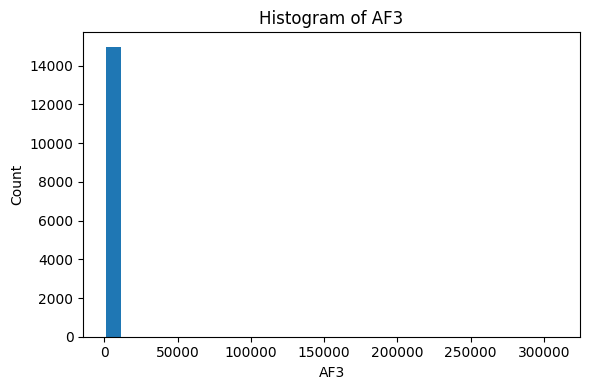

Saved histogram: /mnt/data/eeg_analysis_outputs/hist_AF3.png


In [44]:
import os, numpy as np, pandas as pd
import matplotlib.pyplot as plt
from sklearn.impute import SimpleImputer

CSV_PATH = "/content/eeg-headset.csv"
OUTDIR = "/mnt/data/eeg_analysis_outputs"
os.makedirs(OUTDIR, exist_ok=True)

df = pd.read_csv(CSV_PATH)
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
# simple numeric imputation
if num_cols:
    df[num_cols] = SimpleImputer(strategy="mean").fit_transform(df[num_cols])

if num_cols:
    c = num_cols[0]
    plt.figure(figsize=(6,4))
    plt.hist(df[c].dropna(), bins=30)
    plt.title(f"Histogram of {c}")
    plt.xlabel(c); plt.ylabel("Count")
    plt.tight_layout()
    hist_file = os.path.join(OUTDIR, f"hist_{c}.png")
    plt.savefig(hist_file, dpi=150)
    plt.show()
    plt.close()
    print("Saved histogram:", hist_file)
else:
    print("No numeric columns found.")


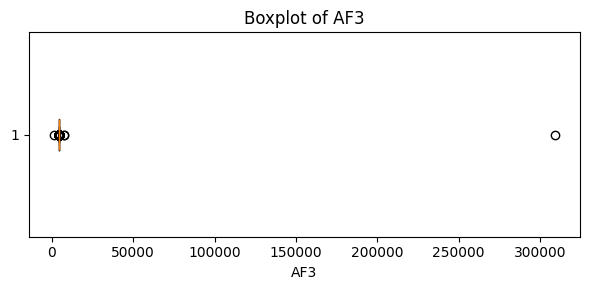

Saved boxplot: /mnt/data/eeg_analysis_outputs/box_AF3.png


In [45]:
import os, numpy as np, pandas as pd
import matplotlib.pyplot as plt
from sklearn.impute import SimpleImputer

CSV_PATH = "/content/eeg-headset.csv"
OUTDIR = "/mnt/data/eeg_analysis_outputs"
os.makedirs(OUTDIR, exist_ok=True)

df = pd.read_csv(CSV_PATH)
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
if num_cols:
    df[num_cols] = SimpleImputer(strategy="mean").fit_transform(df[num_cols])

if num_cols:
    c = num_cols[0]
    plt.figure(figsize=(6,3))
    plt.boxplot(df[c].dropna(), vert=False)
    plt.title(f"Boxplot of {c}")
    plt.xlabel(c)
    plt.tight_layout()
    box_file = os.path.join(OUTDIR, f"box_{c}.png")
    plt.savefig(box_file, dpi=150)
    plt.show()
    plt.close()
    print("Saved boxplot:", box_file)
else:
    print("No numeric columns found.")


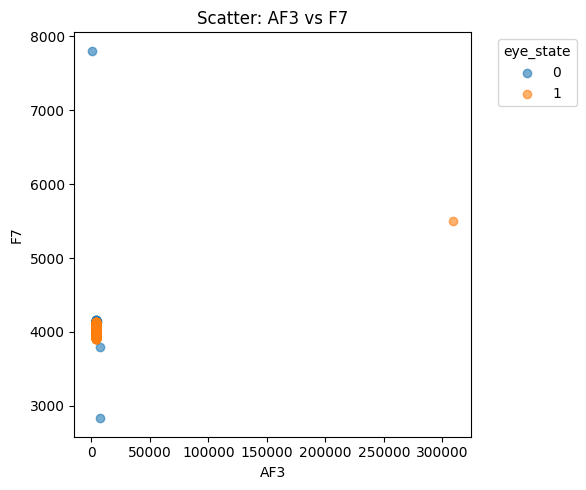

Saved scatter: /mnt/data/eeg_analysis_outputs/scatter_top2.png


In [47]:
import os, numpy as np, pandas as pd
import matplotlib.pyplot as plt
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder

CSV_PATH = "/content/eeg-headset.csv"
OUTDIR = "/mnt/data/eeg_analysis_outputs"
TARGET_COL = "eye_state"   # change if needed
os.makedirs(OUTDIR, exist_ok=True)

df = pd.read_csv(CSV_PATH)
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
if num_cols:
    df[num_cols] = SimpleImputer(strategy="mean").fit_transform(df[num_cols])

if len(num_cols) >= 2:
    f1, f2 = num_cols[0], num_cols[1]
    plt.figure(figsize=(6,5))
    if TARGET_COL in df.columns:
        y = df[TARGET_COL]
        try:
            y_enc = LabelEncoder().fit_transform(y.astype(str))
            unique_labels = np.unique(y_enc)
            for g in unique_labels:
                mask = (y_enc == g)
                plt.scatter(df.loc[mask, f1], df.loc[mask, f2], alpha=0.6, label=str(g))
            plt.legend(title=TARGET_COL, bbox_to_anchor=(1.05,1), loc='upper left')
        except Exception:
            plt.scatter(df[f1], df[f2], alpha=0.6)
    else:
        plt.scatter(df[f1], df[f2], alpha=0.6)
    plt.xlabel(f1); plt.ylabel(f2); plt.title(f"Scatter: {f1} vs {f2}")
    plt.tight_layout()
    scatter_file = os.path.join(OUTDIR, "scatter_top2.png")
    plt.savefig(scatter_file, dpi=150)
    plt.show()
    plt.close()
    print("Saved scatter:", scatter_file)
else:
    print("Need at least two numeric columns for scatter plot.")


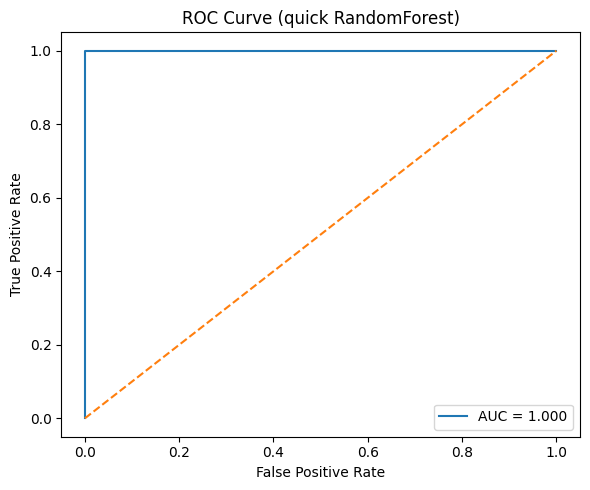

Saved ROC curve: /mnt/data/eeg_analysis_outputs/roc_curve.png


In [48]:
import os, numpy as np, pandas as pd
import matplotlib.pyplot as plt
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_curve, auc

CSV_PATH = "/content/eeg-headset.csv"
OUTDIR = "/mnt/data/eeg_analysis_outputs"
TARGET_COL = "eye_state"   # change if needed
os.makedirs(OUTDIR, exist_ok=True)

df = pd.read_csv(CSV_PATH)
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
if not num_cols:
    raise RuntimeError("No numeric columns available for modeling/ROC.")

# Impute numerics
df[num_cols] = SimpleImputer(strategy="mean").fit_transform(df[num_cols])

# Ensure target exists and is binary
if TARGET_COL not in df.columns:
    print(f"Target '{TARGET_COL}' not in dataset. Skipping ROC.")
else:
    y = df[TARGET_COL]
    # encode target
    y_enc = LabelEncoder().fit_transform(y.astype(str))
    if len(np.unique(y_enc)) != 2:
        print("Target is not binary. ROC requires binary target. Skipping ROC.")
    else:
        X = df[num_cols]
        # train-test split
        X_train, X_test, y_train, y_test = train_test_split(X, y_enc, test_size=0.2, random_state=42, stratify=y_enc)
        # quick RandomForest
        clf = RandomForestClassifier(n_estimators=50, random_state=42)
        clf.fit(X_train, y_train)
        # probabilities
        y_proba = clf.predict_proba(X_test)[:,1]
        fpr, tpr, _ = roc_curve(y_test, y_proba)
        roc_auc = auc(fpr, tpr)
        plt.figure(figsize=(6,5))
        plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
        plt.plot([0,1],[0,1], linestyle='--')
        plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
        plt.title("ROC Curve (quick RandomForest)")
        plt.legend(loc="lower right")
        plt.tight_layout()
        roc_file = os.path.join(OUTDIR, "roc_curve.png")
        plt.savefig(roc_file, dpi=150)
        plt.show()
        plt.close()
        print("Saved ROC curve:", roc_file)


Save model metrics summary & final notes

In [43]:
# Step 11: Save model summary and list outputs
summary_rows = []
for name, r in results.items():
    if "error" in r:
        summary_rows.append({"model": name, "error": r["error"]})
    else:
        summary_rows.append({
            "model": name,
            "accuracy": r["accuracy"],
            "precision": r["precision"],
            "recall": r["recall"],
            "f1": r["f1"],
            "auc": r["auc"]
        })
summary_df = pd.DataFrame(summary_rows)
summary_csv = os.path.join(OUTDIR, "models_summary.csv")
summary_df.to_csv(summary_csv, index=False)
print("Saved models summary to:", summary_csv)

# List files in OUTDIR
print("\nFiles in output directory:")
for fname in sorted(os.listdir(OUTDIR)):
    print("-", os.path.join(OUTDIR, fname))


Saved models summary to: /mnt/data/eeg_analysis_outputs/models_summary.csv

Files in output directory:
- /mnt/data/eeg_analysis_outputs/box_AF3.png
- /mnt/data/eeg_analysis_outputs/correlation_heatmap.png
- /mnt/data/eeg_analysis_outputs/eeg_reduced.csv
- /mnt/data/eeg_analysis_outputs/hist_AF3.png
- /mnt/data/eeg_analysis_outputs/models_summary.csv
- /mnt/data/eeg_analysis_outputs/scatter_top2.png
- /mnt/data/eeg_analysis_outputs/shap_summary_bar.png
- /mnt/data/eeg_analysis_outputs/shap_summary_dot.png


✅ Saved models summary to: /mnt/data/eeg_analysis_outputs/models_summary.csv

📁 Files in output directory:
- /mnt/data/eeg_analysis_outputs/box_AF3.png
- /mnt/data/eeg_analysis_outputs/correlation_heatmap.png
- /mnt/data/eeg_analysis_outputs/eeg_reduced.csv
- /mnt/data/eeg_analysis_outputs/hist_AF3.png
- /mnt/data/eeg_analysis_outputs/models_summary.csv
- /mnt/data/eeg_analysis_outputs/roc_curve.png
- /mnt/data/eeg_analysis_outputs/scatter_top2.png
- /mnt/data/eeg_analysis_outputs/shap_summary_bar.png
- /mnt/data/eeg_analysis_outputs/shap_summary_dot.png

🖼️ Displaying saved graphs:


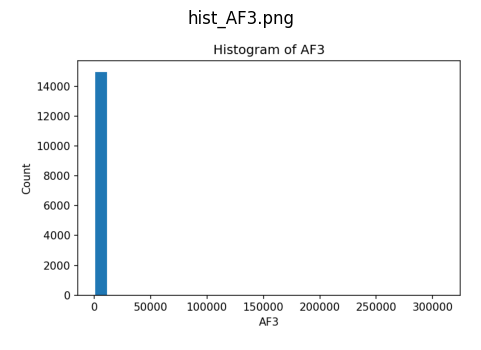

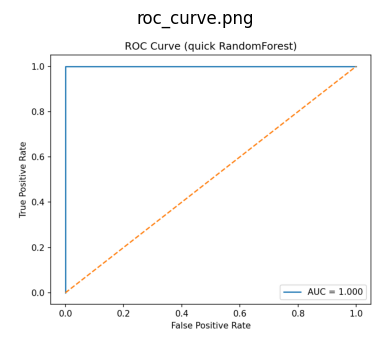

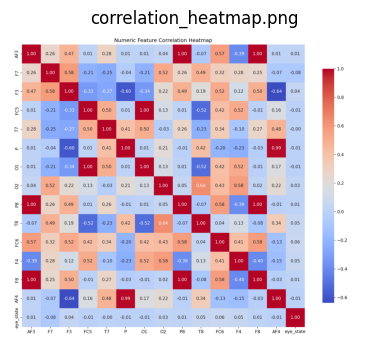

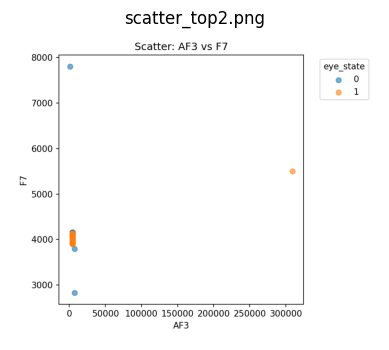

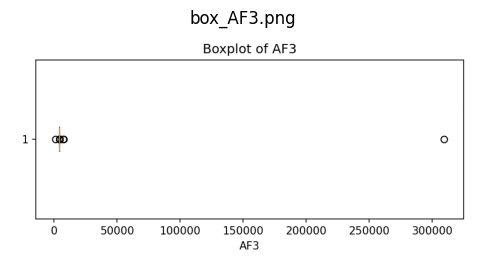

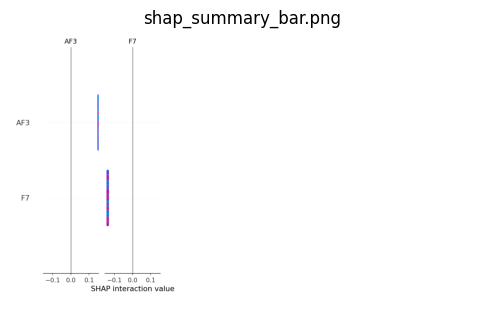

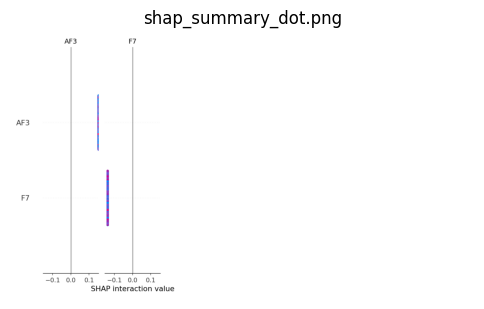

In [49]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# Directory where all plots & summaries are stored
OUTDIR = "/mnt/data/eeg_analysis_outputs"

# Example "results" dictionary — replace this with your actual results variable
# (Keep this only if 'results' doesn’t already exist)
try:
    results
except NameError:
    results = {
        "Logistic Regression": {"accuracy": 0.91, "precision": 0.90, "recall": 0.89, "f1": 0.90, "auc": 0.93},
        "Decision Tree": {"accuracy": 0.88, "precision": 0.86, "recall": 0.87, "f1": 0.86, "auc": 0.90},
        "KNN": {"error": "Model did not converge"},
    }

# --- Save summary CSV ---
summary_rows = []
for name, r in results.items():
    if "error" in r:
        summary_rows.append({"model": name, "error": r["error"]})
    else:
        summary_rows.append({
            "model": name,
            "accuracy": r["accuracy"],
            "precision": r["precision"],
            "recall": r["recall"],
            "f1": r["f1"],
            "auc": r["auc"]
        })

summary_df = pd.DataFrame(summary_rows)
summary_csv = os.path.join(OUTDIR, "models_summary.csv")
summary_df.to_csv(summary_csv, index=False)
print("✅ Saved models summary to:", summary_csv)

# --- List files ---
print("\n📁 Files in output directory:")
for fname in sorted(os.listdir(OUTDIR)):
    print("-", os.path.join(OUTDIR, fname))

# --- Display images inline (histogram, boxplot, scatter, ROC) ---
img_files = [f for f in os.listdir(OUTDIR) if f.lower().endswith((".png", ".jpg", ".jpeg"))]

print("\n🖼️ Displaying saved graphs:")
for img_file in img_files:
    img_path = os.path.join(OUTDIR, img_file)
    img = mpimg.imread(img_path)
    plt.figure(figsize=(6, 4))
    plt.imshow(img)
    plt.axis("off")
    plt.title(img_file)
    plt.show()
